Copyright 2025 Kevin Zambello

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import sys

sys.path.insert(1, '../..')

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import scipy.special

import cpadenn
from cpadenn import Layers, Models, Utils

2025-11-08 09:47:23.870296: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-08 09:47:23.871496: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-08 09:47:23.877886: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-08 09:47:23.896622: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762591643.928251 1632763 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762591643.93

In [2]:
def n_thirring1d(mu, beta=1.0, L=8.0, m=2.0):

    mu = np.complex128(mu)

    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)
    
    res = I1**L * np.sinh(L*mu)
    res = res / (I1**L * np.cosh(L*mu) + I0**L * np.cosh(mtilde))

    return res

In [3]:
def n_thirring1d_sing(beta=1.0, L=8.0, m=2.0):
    
    I0 = scipy.special.iv(0, beta)
    I1 = scipy.special.iv(1, beta)
    mtilde = L*np.asinh(m)

    res = (1.0/L) * np.acosh(   np.complex128(- I0**L / I1**L * np.cosh(mtilde))   )
    
    res_arr = res + np.array([1.0j*2.0*np.pi*n/L for n in range(-5,5)])
    res_arr = np.append(res_arr, -res_arr)

    return res_arr

Text(0.5, 0, '$Re[\\mu]$')

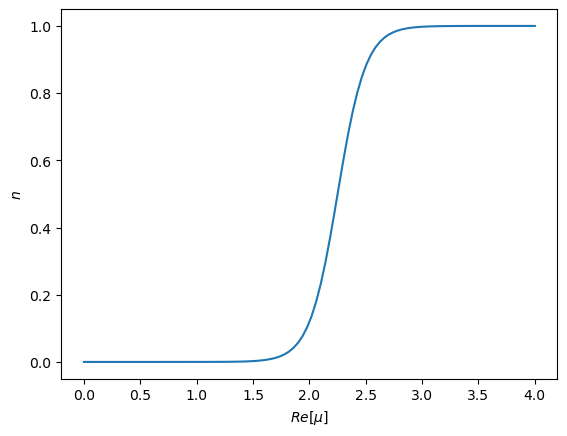

In [4]:
mymu = np.linspace(0., 4., 100)
plt.plot(mymu, n_thirring1d(mymu).real)
plt.ylabel('$n$')
plt.xlabel('$Re[\mu]$')

In [5]:
n_thirring1d_sing()

array([ 2.25019782-3.53429174j,  2.25019782-2.74889357j,
        2.25019782-1.96349541j,  2.25019782-1.17809725j,
        2.25019782-0.39269908j,  2.25019782+0.39269908j,
        2.25019782+1.17809725j,  2.25019782+1.96349541j,
        2.25019782+2.74889357j,  2.25019782+3.53429174j,
       -2.25019782+3.53429174j, -2.25019782+2.74889357j,
       -2.25019782+1.96349541j, -2.25019782+1.17809725j,
       -2.25019782+0.39269908j, -2.25019782-0.39269908j,
       -2.25019782-1.17809725j, -2.25019782-1.96349541j,
       -2.25019782-2.74889357j, -2.25019782-3.53429174j])

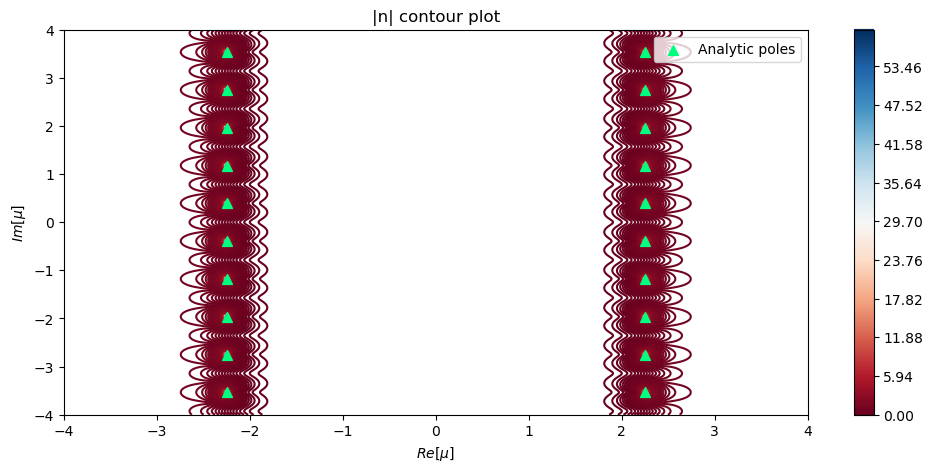

In [6]:
pts = 500
xg = np.linspace(-4, 4, pts)
yg = np.linspace(-4, 4, pts)
Xg, Yg = np.meshgrid(xg, yg)
Zg = Xg + 1.0j*Yg
out = n_thirring1d(Zg)

real_out = out.reshape(Xg.shape)
imag_out = out.imag.reshape(Yg.shape)
abs_out = np.abs(real_out + 1.0j * imag_out)

analytic_sings = n_thirring1d_sing()

plt.figure(figsize=(12, 5))
plt.contour(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
#plt.contourf(Xg, Yg, abs_out, levels=1000, cmap='RdBu')
plt.colorbar()
plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$Im[\mu]$')
plt.title('|n| contour plot')
plt.legend()

Text(0.5, 1.0, 'Test data')

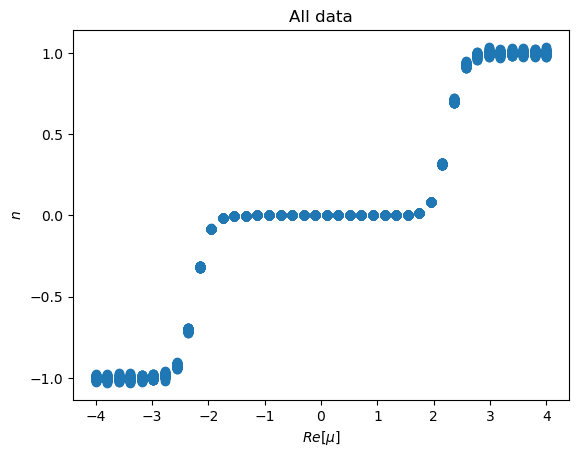

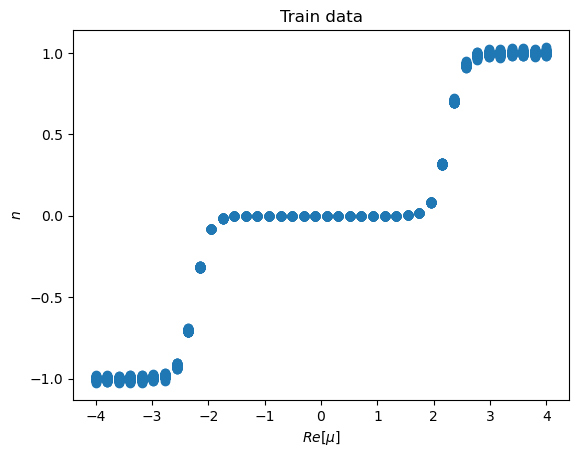

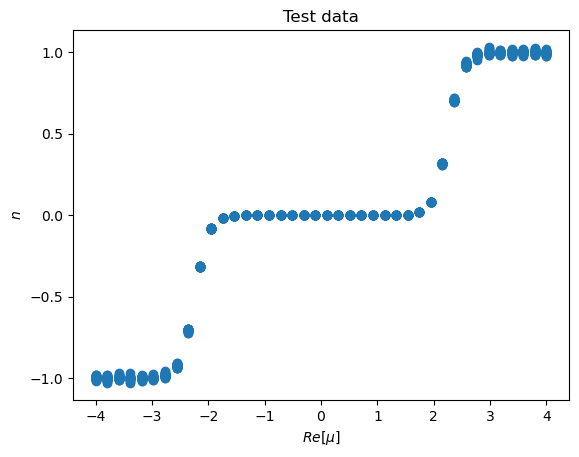

In [7]:
epsilon = 1.0e-2

mu_ = np.linspace(-4.0,4.0,40)
n_ = n_thirring1d(mu_)
dn_ = np.abs(n_) * epsilon

mu_sampled = mu_ 
n_sampled = n_ + dn_*np.random.randn(dn_.size)

for n in np.arange(100):
    mu_sampled = np.append(mu_sampled, mu_)
    n_sampled = np.append(n_sampled, n_ + dn_*np.random.randn(dn_.size))
    
X = np.transpose(np.stack([np.real(mu_sampled), np.imag(mu_sampled)]))
Y = np.transpose(np.stack([np.real(n_sampled), np.imag(n_sampled)]))

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('All data')

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

plt.figure()
plt.plot(X_train[:,0], Y_train[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Train data')

plt.figure()
plt.plot(X_test[:,0], Y_test[:,0], 'o', ls='')
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')
plt.title('Test data')

In [8]:
modelNN_run1 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run1 = modelNN_run1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run1.summary())

Epoch 1/2000


2025-11-08 09:47:35.036364: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - loss: 14.2419 - val_loss: 3.8717
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.6764 - val_loss: 3.2410
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.0057 - val_loss: 2.7998
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6653 - val_loss: 2.5255
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.3958 - val_loss: 2.3094
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.2271 - val_loss: 2.1117
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.0555 - val_loss: 1.9243
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.8407 - val_loss: 1.7426
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6594 - val_loss: 1.5525
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.4670 - val_loss: 1.3387
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3178 - val_loss: 1.2222
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1214 - val_loss: 0.1207
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1196 - val_loss: 0.1203
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1197 - val_loss: 0.1200
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1208 - val_loss: 0.1196
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1199 - val_loss: 0.1193
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1187 - val_loss: 0.1189
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1183 - val_loss: 0.1186
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1180 - val_loss: 0.1183
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1182 - val_loss: 0.1180
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1178 - val_loss: 0.1177
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1178 - val_loss: 0.1175
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1072 - val_loss: 0.1070
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1070 - val_loss: 0.1068
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1069 - val_loss: 0.1067
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1066 - val_loss: 0.1065
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1062 - val_loss: 0.1063
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1063 - val_loss: 0.1061
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1061 - val_loss: 0.1060
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1059 - val_loss: 0.1058
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1056 - val_loss: 0.1056
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1054 - val_loss: 0.1054
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1052 - val_loss: 0.1053
Epoch 146/2000
23/23 

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [9]:
modelNN_run2 = cpadenn.Models.PadeModel(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_run2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_run2 = modelNN_run2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_run2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 8.1986 - val_loss: 3.6382
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.7487 - val_loss: 1.3844
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1506 - val_loss: 0.7899
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7070 - val_loss: 0.5182
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4633 - val_loss: 0.3667
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3283 - val_loss: 0.2670
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2448 - val_loss: 0.2034
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1860 - val_loss: 0.1617
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1531 - val_loss: 0.1324
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1271 - val_loss: 0.1117
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1081 - val_loss: 0.0971
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0588 - val_loss: 0.0590
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0587 - val_loss: 0.0589
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0586 - val_loss: 0.0587
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0583 - val_loss: 0.0585
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0582 - val_loss: 0.0583
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0581 - val_loss: 0.0582
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0579 - val_loss: 0.0582
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0578 - val_loss: 0.0579
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0576 - val_loss: 0.0577
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0573 - val_loss: 0.0575
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0572 - val_loss: 0.0574
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0498 - val_loss: 0.0498
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0496 - val_loss: 0.0494
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0492 - val_loss: 0.0492
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0491 - val_loss: 0.0491
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0490 - val_loss: 0.0490
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0489 - val_loss: 0.0491
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0488 - val_loss: 0.0490
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0493 - val_loss: 0.0490
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0488 - val_loss: 0.0493
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0488 - val_loss: 0.0490
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0486 - val_loss: 0.0491
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0411 - val_loss: 0.0404
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0404 - val_loss: 0.0406
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0407 - val_loss: 0.0401
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0402 - val_loss: 0.0406
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0406 - val_loss: 0.0404
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0400 - val_loss: 0.0399
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0397 - val_loss: 0.0398
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0403 - val_loss: 0.0401
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0397 - val_loss: 0.0397
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0394 - val_loss: 0.0395
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0394 - val_loss: 0.0391
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0307 - val_loss: 0.0304
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0304 - val_loss: 0.0304
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0302 - val_loss: 0.0307
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0302 - val_loss: 0.0300
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0300 - val_loss: 0.0298
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0297 - val_loss: 0.0296
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0296 - val_loss: 0.0295
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0294 - val_loss: 0.0293
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0293 - val_loss: 0.0295
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0293 - val_loss: 0.0290
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0289 - val_loss: 0.0290
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 452 (1.77 KB)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 302 (1.18 KB)

None


In [10]:
modelNN_baseline1 = cpadenn.Models.BaselineModel1(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline1.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline1 = modelNN_baseline1.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline1.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 27.0826 - val_loss: 21.4157
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.7917 - val_loss: 15.5910
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 14.4086 - val_loss: 11.2947
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 10.4001 - val_loss: 8.2043
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.4794 - val_loss: 6.0364
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.6325 - val_loss: 4.5682
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.2440 - val_loss: 3.5928
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.3249 - val_loss: 2.9542
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7295 - val_loss: 2.5291
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4044 - val_loss: 2.2475
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.2055 - val_loss: 2.0516
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1386 - val_loss: 0.1388
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1379 - val_loss: 0.1375
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1364 - val_loss: 0.1363
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1349 - val_loss: 0.1352
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1335 - val_loss: 0.1340
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1328 - val_loss: 0.1328
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1321 - val_loss: 0.1317
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1313 - val_loss: 0.1306
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1286 - val_loss: 0.1295
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1276 - val_loss: 0.1284
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1283 - val_loss: 0.1273
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0972 - val_loss: 0.0975
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0969 - val_loss: 0.0972
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0971 - val_loss: 0.0970
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0964 - val_loss: 0.0968
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0965 - val_loss: 0.0966
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0958 - val_loss: 0.0963
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0954 - val_loss: 0.0961
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0951 - val_loss: 0.0959
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0951 - val_loss: 0.0957
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0947 - val_loss: 0.0955
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0946 - val_loss: 0.0953
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0837 - val_loss: 0.0844
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0831 - val_loss: 0.0842
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0836 - val_loss: 0.0840
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0834 - val_loss: 0.0838
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0836 - val_loss: 0.0836
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0829 - val_loss: 0.0834
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0826 - val_loss: 0.0832
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0824 - val_loss: 0.0830
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0823 - val_loss: 0.0828
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0822 - val_loss: 0.0826
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0822 - val_loss: 0.0824
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0700 - val_loss: 0.0705
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0701 - val_loss: 0.0703
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0697 - val_loss: 0.0701
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0696 - val_loss: 0.0699
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0695 - val_loss: 0.0697
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0689 - val_loss: 0.0695
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0687 - val_loss: 0.0692
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0683 - val_loss: 0.0691
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0681 - val_loss: 0.0687
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0680 - val_loss: 0.0684
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0681 - val_loss: 0.0683
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 344 (1.35 KB)

 Trainable params: 114 (456.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 230 (924.00 B)

None


In [11]:
modelNN_baseline2 = cpadenn.Models.BaselineModel2(fugacity=False)
optadam = tf.keras.optimizers.Adam(learning_rate=1.0e-3)

modelNN_baseline2.compile(optimizer = optadam, loss='mean_squared_error')

EarlyStop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

histNN_baseline2 = modelNN_baseline2.fit(X_train, Y_train, epochs=2000, batch_size=128, validation_data=(X_test, Y_test), callbacks=[EarlyStop])

print(modelNN_baseline2.summary())

Epoch 1/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 28.5444 - val_loss: 19.6514
Epoch 2/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 17.5217 - val_loss: 12.4469
Epoch 3/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 11.1925 - val_loss: 8.4013
Epoch 4/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.6232 - val_loss: 6.0044
Epoch 5/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.5576 - val_loss: 4.5071
Epoch 6/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.2179 - val_loss: 3.5363
Epoch 7/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.2662 - val_loss: 2.8956
Epoch 8/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7342 - val_loss: 2.4631
Epoch 9/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.3539 - val_loss: 2.1563
Epoch 10/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.0818 - val_loss: 1.9364
Epoch 11/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8639 - val_loss: 1.7700
Epoch 12/2000
23/23 ━━━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1326 - val_loss: 0.1328
Epoch 69/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1315 - val_loss: 0.1323
Epoch 70/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1311 - val_loss: 0.1318
Epoch 71/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1306 - val_loss: 0.1313
Epoch 72/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1299 - val_loss: 0.1309
Epoch 73/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1297 - val_loss: 0.1304
Epoch 74/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1291 - val_loss: 0.1300
Epoch 75/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1289 - val_loss: 0.1295
Epoch 76/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1284 - val_loss: 0.1291
Epoch 77/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1281 - val_loss: 0.1287
Epoch 78/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1277 - val_loss: 0.1282
Epoch 79/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11

Epoch 135/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1111 - val_loss: 0.1118
Epoch 136/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1110 - val_loss: 0.1116
Epoch 137/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1108 - val_loss: 0.1114
Epoch 138/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1112 - val_loss: 0.1111
Epoch 139/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1106 - val_loss: 0.1109
Epoch 140/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1099 - val_loss: 0.1107
Epoch 141/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1098 - val_loss: 0.1104
Epoch 142/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1096 - val_loss: 0.1102
Epoch 143/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1097 - val_loss: 0.1101
Epoch 144/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1093 - val_loss: 0.1098
Epoch 145/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1089 - val_loss: 0.1096
Epoch 146/2000
23/23 

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0965 - val_loss: 0.0968
Epoch 202/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0963 - val_loss: 0.0965
Epoch 203/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0962 - val_loss: 0.0963
Epoch 204/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0958 - val_loss: 0.0961
Epoch 205/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0959 - val_loss: 0.0958
Epoch 206/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0956 - val_loss: 0.0956
Epoch 207/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0952 - val_loss: 0.0954
Epoch 208/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0951 - val_loss: 0.0952
Epoch 209/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0944 - val_loss: 0.0949
Epoch 210/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0946 - val_loss: 0.0949
Epoch 211/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0946 - val_loss: 0.0944
Epoch 212/2000
23/23 ━━━━━━━━━━━━━━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0798 - val_loss: 0.0798
Epoch 268/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0794 - val_loss: 0.0797
Epoch 269/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0792 - val_loss: 0.0793
Epoch 270/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0788 - val_loss: 0.0790
Epoch 271/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0789 - val_loss: 0.0787
Epoch 272/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0783 - val_loss: 0.0784
Epoch 273/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0781 - val_loss: 0.0782
Epoch 274/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0779 - val_loss: 0.0782
Epoch 275/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0773 - val_loss: 0.0776
Epoch 276/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0773 - val_loss: 0.0773
Epoch 277/2000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0768 - val_loss: 0.0770
Epoch 278/2000
23/23 ━━━━━━━━━━━━━━━

...

 Total params: 464 (1.82 KB)

 Trainable params: 154 (616.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 310 (1.21 KB)

None


Text(0, 0.5, 'Loss')

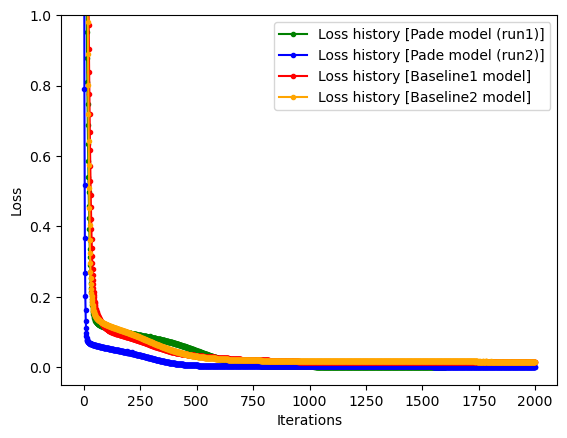

In [12]:
loss_NN_run1 = histNN_run1.history['val_loss']
loss_NN_run2 = histNN_run2.history['val_loss']
loss_NN_baseline1 = histNN_baseline1.history['val_loss']
loss_NN_baseline2 = histNN_baseline2.history['val_loss']

plt.plot(loss_NN_run1, label='Loss history [Pade model (run1)]', marker='.', color='green')
plt.plot(loss_NN_run2, label='Loss history [Pade model (run2)]', marker='.', color='blue')
plt.plot(loss_NN_baseline1, label='Loss history [Baseline1 model]', marker='.', color='red')
plt.plot(loss_NN_baseline2, label='Loss history [Baseline2 model]', marker='.', color='orange')
plt.legend()
plt.ylim([-0.05,1])
plt.xlabel('Iterations')
plt.ylabel('Loss')

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


Text(0, 0.5, '$n$')

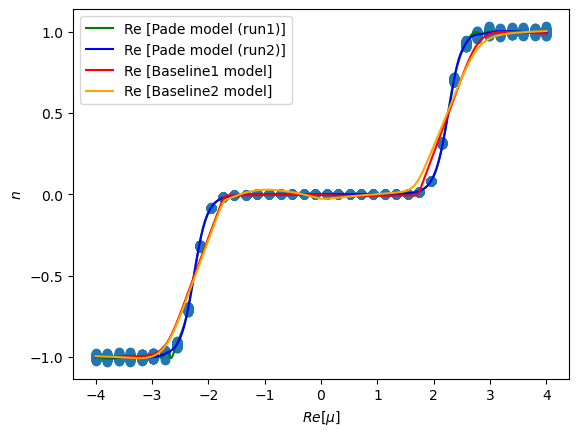

In [13]:
mu_pred = np.linspace(-4,4,1000)

X_pred = np.transpose(np.stack([np.real(mu_pred), np.imag(mu_pred)]))
Y_pred_NN_run1 = modelNN_run1.predict(X_pred)
Y_pred_NN_run2 = modelNN_run2.predict(X_pred)
Y_pred_NN_baseline1 = modelNN_baseline1.predict(X_pred)
Y_pred_NN_baseline2 = modelNN_baseline2.predict(X_pred)

plt.figure()
plt.plot(X[:,0], Y[:,0], 'o', ls='')
plt.plot(X_pred[:,0], Y_pred_NN_run1[:,0], color='green', label='Re [Pade model (run1)]')
plt.plot(X_pred[:,0], Y_pred_NN_run2[:,0], color='blue', label='Re [Pade model (run2)]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline1[:,0], color='red', label='Re [Baseline1 model]')
plt.plot(X_pred[:,0], Y_pred_NN_baseline2[:,0], color='orange', label='Re [Baseline2 model]')
plt.legend()
plt.xlabel('$Re[\mu]$')
plt.ylabel('$n$')

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


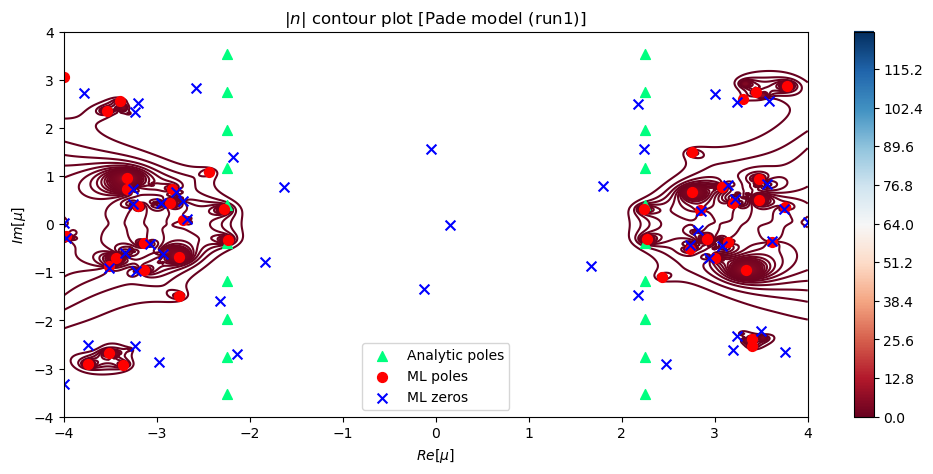

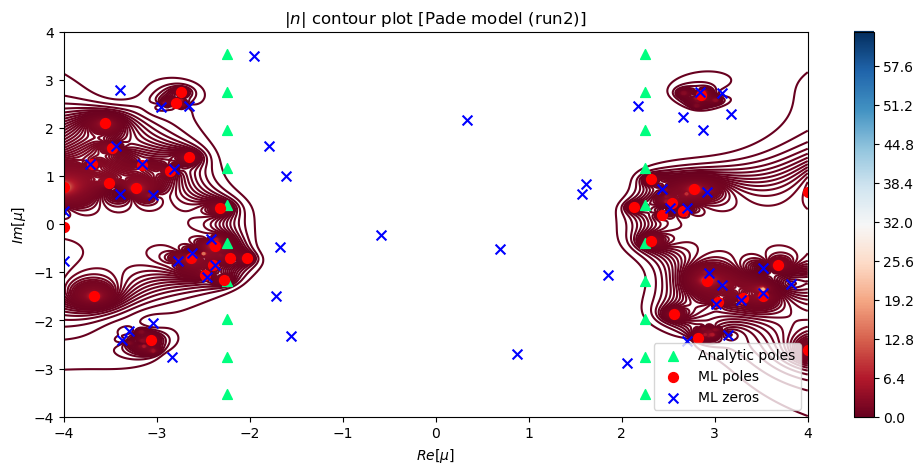

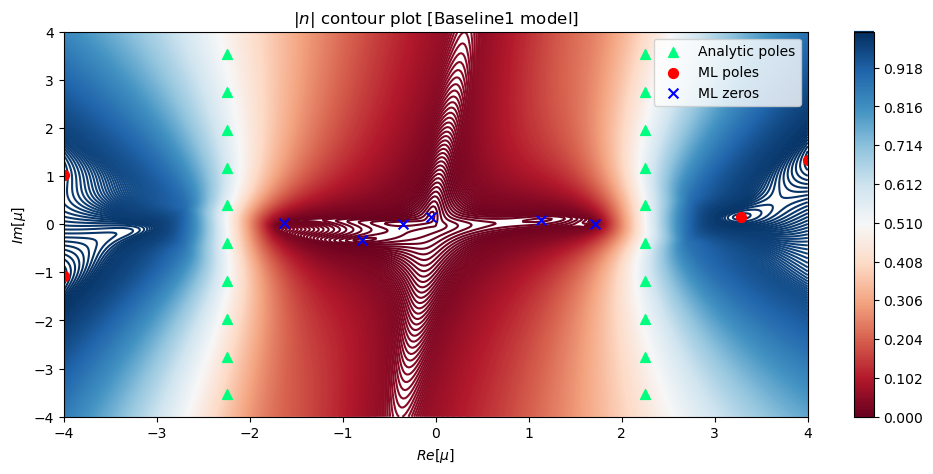

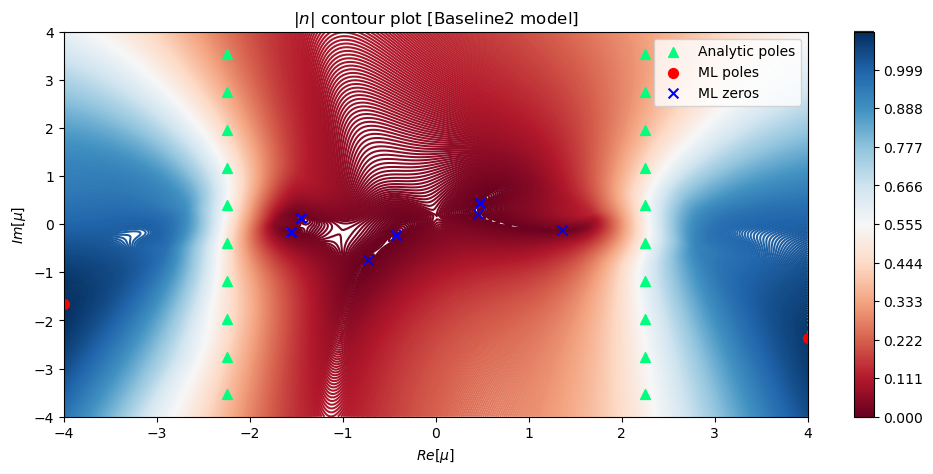

In [14]:
models = [modelNN_run1, modelNN_run2, modelNN_baseline1, modelNN_baseline2]
names = ['Pade model (run1)', 'Pade model (run2)', 'Baseline1 model', 'Baseline2 model']
for n in np.arange(4):
    pts = 400
    xg = np.linspace(-4, 4, pts)
    yg = np.linspace(-4, 4, pts)
    Xg, Yg = np.meshgrid(xg, yg)
    Zg = np.stack([Xg.ravel(), Yg.ravel()], axis=-1).astype(np.float32)
    out = models[n].predict(Zg)

    real_out = out[:, 0].reshape(Xg.shape)
    imag_out = out[:, 1].reshape(Yg.shape)
    abs_out = np.abs(real_out + 1.0j * imag_out)

    poles = cpadenn.Utils.FindLocMax(Xg, Yg, abs_out)
    zeros = cpadenn.Utils.FindLocMax(Xg, Yg, 1.0/abs_out)

    analytic_sings = n_thirring1d_sing()

    plt.figure(figsize=(12, 5))
    plt.contour(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    #plt.contourf(Xg, Yg, abs_out, levels=800, cmap='RdBu')
    plt.colorbar()
    plt.scatter(analytic_sings.real, analytic_sings.imag, color='springgreen', marker='^', s=50, zorder=2, label='Analytic poles')
    plt.scatter(poles[:,0], poles[:,1], color='red', marker='o', s=50, zorder=2, label='ML poles')
    plt.scatter(zeros[:,0], zeros[:,1], color='blue', marker='x', s=50, zorder=2, label='ML zeros')
    plt.xlabel('$Re[\mu]$')
    plt.ylabel('$Im[\mu]$')
    plt.title(f"$|n|$ contour plot [{names[n]}]")
    plt.legend()